# LSTM Anomaly Detection

### Data Loading

In [2]:
import pandas as pd
import numpy as np
import glob

In [3]:
valve_files = sorted( glob.glob('SKAB_data/valve1/*.csv'))

df = pd.concat([ pd.read_csv( f, sep=';', index_col='datetime', parse_dates=True ) for f in valve_files ])

print(f'Files loaded: {len(valve_files)}')
print(df.shape)
print(df['anomaly'].value_counts())

Files loaded: 16
(18162, 10)
anomaly
0.0    11853
1.0     6309
Name: count, dtype: int64


In [4]:
print(df.shape) 
print(df.columns.tolist())
print(df['anomaly'].value_counts()) 

(18162, 10)
['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS', 'anomaly', 'changepoint']
anomaly
0.0    11853
1.0     6309
Name: count, dtype: int64


### Preprocessing

In [5]:
from sklearn.preprocessing import MinMaxScaler

feature_cols = [c for c in df.columns if c not in ['anomaly', 'changepoint']]
X = df[feature_cols].values
y = df['anomaly'].values


In [6]:
normal_mask = (y == 0)

scaler = MinMaxScaler()
scaler.fit(X[normal_mask])

X_scaled = scaler.transform(X)

In [7]:
# Split: only training on normal data (unsupervised)
normal_mask = (y == 0)
X_normal = X_scaled[normal_mask]
print(f'Normal samples: {X_normal.shape[0]}, Anomaly samples: {(y==1).sum()}')

Normal samples: 11853, Anomaly samples: 6309


In [8]:
# sliding window 
def make_windows(data, window_size):
    windows = []
    for i in range(len(data) - window_size):
        windows.append(data[i:i+window_size])

    return np.array(windows)

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [10]:
def prepare_tensors(X_train, X_all):
    X_train_t = torch.FloatTensor(X_train)
    X_all_t = torch.FloatTensor(X_all)

    dataset = TensorDataset(X_train_t, X_train_t)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

    return X_train_t, X_all_t, dataloader

### Lstm Autoencoder

In [11]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=2):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.encoder = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )

        self.decoder = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )

        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        _, (hidden, cell) = self.encoder(x)
        decoder_input = hidden[-1].unsqueeze(1).repeat(1, seq_len, 1)
        decoder_out, _ = self.decoder(decoder_input)
        reconstructed = self.output_layer(decoder_out)
        return reconstructed

### Hyper parameter Tuning

In [12]:
from sklearn.metrics import f1_score, roc_auc_score

In [13]:
WINDOWS = [10, 20, 30]
HIDDENS = [32, 64]

In [14]:
def train_model(model, dataloader, epochs):

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        model.train()

        for batch_x, batch_y in dataloader:
            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

In [15]:
results = []

for WINDOW in WINDOWS:
    X_train = make_windows(X_normal, WINDOW)
    X_all = make_windows(X_scaled, WINDOW)
    y_all = y[WINDOW:]

    X_train_t, X_all_t, dataloader = prepare_tensors(X_train, X_all)

    for HIDDEN_DIM in HIDDENS:
        print(f"\nWINDOW={WINDOW} | HIDDEN={HIDDEN_DIM}")
        model = LSTMAutoencoder(input_dim=X_train.shape[2],hidden_dim=HIDDEN_DIM )
        train_model(model, dataloader, 30)

        model.eval()

        with torch.no_grad():
            reconstructed = model(X_all_t)
            mse_errors = torch.mean((X_all_t - reconstructed)**2, dim=(1,2) ).numpy()
            train_recon = model(X_train_t)
            train_errors = torch.mean( (X_train_t - train_recon)**2, dim=(1,2) ).numpy()

        threshold = np.percentile(train_errors, 95 )
        y_pred = ( mse_errors > threshold).astype(int)

        f1 = f1_score(y_all,y_pred)
        auc = roc_auc_score( y_all, mse_errors )

        results.append( [ WINDOW, HIDDEN_DIM, f1,auc ])
        print( f"F1={f1:.4f} | "f"AUC={auc:.4f}")


WINDOW=10 | HIDDEN=32
F1=0.7106 | AUC=0.8127

WINDOW=10 | HIDDEN=64
F1=0.7320 | AUC=0.8437

WINDOW=20 | HIDDEN=32
F1=0.7452 | AUC=0.8256

WINDOW=20 | HIDDEN=64
F1=0.7475 | AUC=0.8440

WINDOW=30 | HIDDEN=32
F1=0.7780 | AUC=0.8770

WINDOW=30 | HIDDEN=64
F1=0.7736 | AUC=0.8706


In [16]:
results_df = pd.DataFrame(
    results,
    columns=[ "Window", "Hidden", "F1","AUC" ] )

results_df.sort_values( by="F1",ascending=False )

,Window,Hidden,F1,AUC
4,30,32,0.778015,0.877012
5,30,64,0.773571,0.870633
3,20,64,0.747473,0.844002
2,20,32,0.745159,0.825556
1,10,64,0.731990,0.843667
0,10,32,0.710649,0.812721


In [17]:
best = results_df.sort_values("F1", ascending=False).iloc[0]

WINDOW = int(best["Window"])
HIDDEN_DIM = int(best["Hidden"])

### Training Model

In [18]:
X_train = make_windows(X_normal, WINDOW) # shape: (N, 30, 8)
X_all = make_windows(X_scaled, WINDOW) 
y_all = y[WINDOW:] 
print(f'Train shape: {X_train.shape}, All shape: {X_all.shape}')

Train shape: (11823, 30, 8), All shape: (18132, 30, 8)


In [19]:
# Initialize model
INPUT_DIM = X_train.shape[2]
model = LSTMAutoencoder(INPUT_DIM, HIDDEN_DIM)
print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

LSTMAutoencoder(
  (encoder): LSTM(8, 32, num_layers=2, batch_first=True, dropout=0.2)
  (decoder): LSTM(32, 32, num_layers=2, batch_first=True, dropout=0.2)
  (output_layer): Linear(in_features=32, out_features=8, bias=True)
)
Parameters: 30,984


In [20]:
X_train_t, X_all_t, dataloader = prepare_tensors(X_train, X_all)

In [21]:
train_model(model, dataloader, 50)

### Evaluation

In [22]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report
from sklearn.ensemble import IsolationForest

model.eval()

LSTMAutoencoder(
  (encoder): LSTM(8, 32, num_layers=2, batch_first=True, dropout=0.2)
  (decoder): LSTM(32, 32, num_layers=2, batch_first=True, dropout=0.2)
  (output_layer): Linear(in_features=32, out_features=8, bias=True)
)

In [23]:
with torch.no_grad():
    # reconstruction errors on (normal + anomaly data)
    reconstructed = model(X_all_t)
    mse_errors = torch.mean((X_all_t - reconstructed)**2, dim=(1,2)).numpy()

# threshhold= 95%ile of train error
with torch.no_grad():
    train_recon = model(X_train_t)
    train_errors = torch.mean((X_train_t - train_recon)**2, dim=(1,2)).numpy()

THRESHOLD = np.percentile(train_errors, 95)

print(f'Anomaly threshold: {THRESHOLD:.4f}')

Anomaly threshold: 0.0055


In [24]:
# reconstruction error > threshold = 1
y_pred_lstm = (mse_errors > THRESHOLD).astype(int)

In [25]:
#LSTM Autoencoder
f1_lstm = f1_score(y_all, y_pred_lstm)
auc_lstm = roc_auc_score(y_all, mse_errors)

print(f'\nLSTM Autoencoder')
print(f'F1 Score: {f1_lstm:.4f}')
print(f'AUC-ROC: {auc_lstm:.4f}')
print(classification_report(y_all, y_pred_lstm))


LSTM Autoencoder
F1 Score: 0.7920
AUC-ROC: 0.8853
              precision    recall  f1-score   support

         0.0       0.86      0.95      0.91     11823
         1.0       0.89      0.71      0.79      6309

    accuracy                           0.87     18132
   macro avg       0.88      0.83      0.85     18132
weighted avg       0.87      0.87      0.87     18132



In [26]:
# Baseline= Isolation Forest
X_normal_windows = make_windows(X_normal, WINDOW)

iso = IsolationForest( contamination=0.05, random_state=42)
iso.fit(X_normal_windows.reshape(len(X_normal_windows), -1))
iso_scores = -iso.score_samples( X_all.reshape(len(X_all), -1))

y_pred_iso = (iso.predict(X_all.reshape(len(X_all), -1)) == -1).astype(int)

In [27]:
f1_iso = f1_score(y_all, y_pred_iso)
auc_iso = roc_auc_score(y_all, iso_scores)

print(f'\nBaseline Isolation Forest')
print(f'F1 Score: {f1_iso:.4f}')
print(f'AUC-ROC: {auc_iso:.4f}')

print(
    f'\nLSTM F1 improvement over baseline: '
    f'+{(f1_lstm - f1_iso)*100:.1f}%'
)


Baseline Isolation Forest
F1 Score: 0.6299
AUC-ROC: 0.8780

LSTM F1 improvement over baseline: +16.2%


### Visualisation

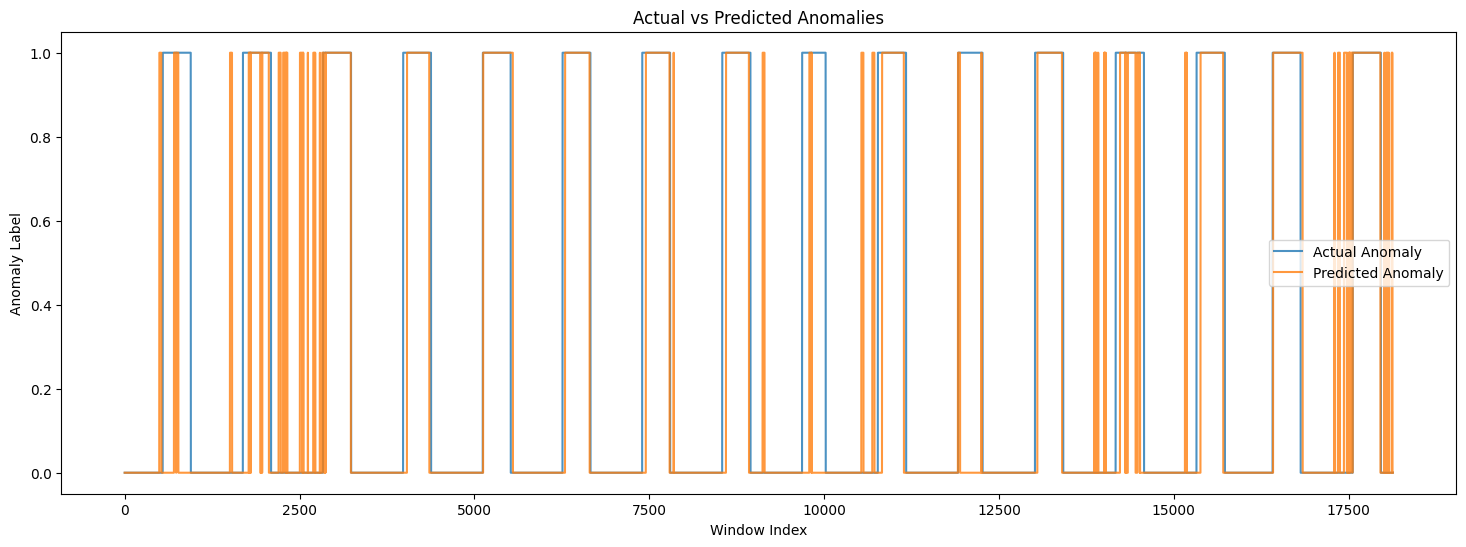

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,6))

plt.plot(y_all, label='Actual Anomaly', alpha=0.8)

plt.plot( y_pred_lstm, label='Predicted Anomaly', alpha=0.8 )

plt.xlabel('Window Index')
plt.ylabel('Anomaly Label')
plt.title('Actual vs Predicted Anomalies')

plt.legend()
plt.show()

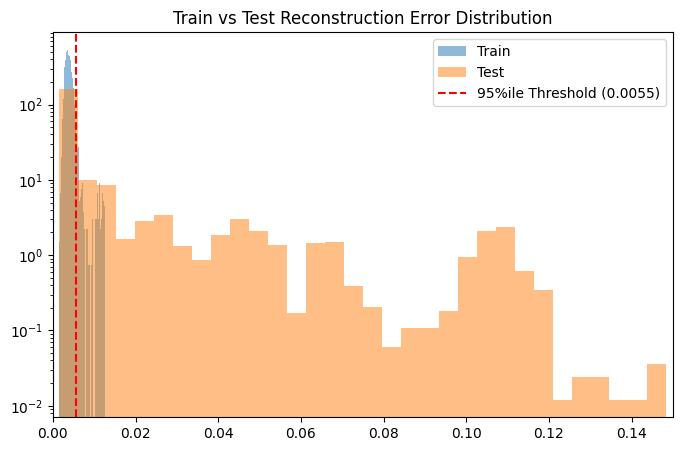

Train Error Mean : 0.003931
Test Error Mean  : 0.023290
Threshold        : 0.005480


In [29]:
plt.figure(figsize=(8,5))
plt.hist(train_errors,bins=100,alpha=0.5,label='Train',density=True)
plt.hist(mse_errors,bins=100,alpha=0.5,label='Test',density=True)

plt.axvline(
    THRESHOLD,
    color='red',
    linestyle='--',
    label=f'95%ile Threshold ({THRESHOLD:.4f})'
)

plt.xlim(0,0.15)
plt.yscale('log')
plt.title('Train vs Test Reconstruction Error Distribution')
plt.legend()
plt.show()
print(f"Train Error Mean : {train_errors.mean():.6f}")
print(f"Test Error Mean  : {mse_errors.mean():.6f}")
print(f"Threshold        : {THRESHOLD:.6f}")

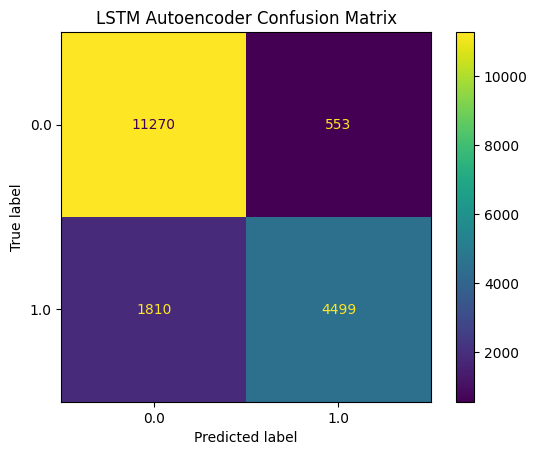

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_all, y_pred_lstm)
plt.title("LSTM Autoencoder Confusion Matrix")
plt.show()

### Conclusion


### Conclusion

- Hyperparameter tuning identified Window Size = 30 and Hidden Dimension = 32 as the best-performing configuration.
- The final LSTM Autoencoder achieved an F1 Score of 0.792 and an AUC-ROC of 0.885 on the SKAB dataset.
- The model outperformed the Isolation Forest baseline by 16.2 percentage points in F1 Score.
- Reconstruction error distributions showed clear separation between normal and anomalous operating conditions.
- Results demonstrate that LSTM Autoencoders can effectively learn temporal patterns in industrial sensor data for unsupervised anomaly detection.